# Step 1 — Hindcast Evaluation of SCI Ensemble
## CO₂ Emissions (Energy and Industrial Processes)

We compare the SCI 2025 scenario ensemble against observed data (GCB 2025, IEA).

Three metrics:
- **ME** (Mean Error): systematic bias — sign tells direction
- **MAE** (Mean Absolute Error): typical error magnitude
- **RMSE**: penalises large deviations

Three views:
- **View 1**: averaged over scenarios → one value per year
- **View 2**: averaged over time → one value per scenario (distribution)
- **View 3**: averaged over both → single number

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── EACH USER: update this path ──
SCI_DATA = Path.home() / 'PhD' / '4. Modeling' / 'Prisma School' / 'Scenario_Compass_Initiative_Data'
SCI_FILE = SCI_DATA / 'SCI-2025_v1.0_pathways_ensemble_global.xlsx'

## Load data

In [2]:
df = pd.read_excel(SCI_FILE, sheet_name='data')
meta = pd.read_excel(SCI_FILE, sheet_name='meta')
print(f'Data: {len(df)} rows, {df["Model"].nunique()} models, {df["Scenario"].nunique()} scenarios')

Data: 548541 rows, 65 models, 666 scenarios


In [3]:
# NZ2070 flag
meta['nz_year'] = pd.to_numeric(meta['Emissions Diagnostics|Year of Net Zero|CO2'], errors='coerce')
meta['nz2070'] = meta['nz_year'].notna() & (meta['nz_year'] <= 2070)
meta['key'] = meta['Model'] + '|||' + meta['Scenario']
nz_keys = set(meta.loc[meta['nz2070'], 'key'])
print(f'NZ2070: {len(nz_keys)} scenarios')

NZ2070: 497 scenarios


## Filter to CO₂ and compute errors

**Ensemble weighting.** The raw ensemble is unbalanced: a few prolific teams (REMIND, MESSAGE)
contribute hundreds of scenarios while many models contribute 1–2, so scenario-level averages
mostly reflect *who submitted the most runs*. Set `WEIGHTING` below:
- `'scenario'` — every scenario counts equally (original behaviour)
- `'model'` — every model **version** counts equally (weight 1/n per Model)
- `'family'` — every model **family** counts equally (weight 1/n per Family) → most balanced

Weights act *across* scenarios; within a scenario the per-year spread is untouched, and weights
are re-balanced inside each group (NZ / non-NZ) so the comparison stays fair.

**Model class.** Each family is also tagged by economic structure:
- `'economy'` — endogenous macro-economy: CGE (AIM, GEM-E3, IMACLIM, EPPA, CGEM) or
  inter-temporal/Ramsey growth (REMIND, WITCH, MERGE)
- `'energy'` — energy-system / partial-equilibrium, GDP ~ exogenous (MESSAGE, IMAGE, POLES,
  COFFEE, GCAM, TIAM, PROMETHEUS)
- `'other'` — reduced-form / unclassified (C-ROADS, MINES)

In [4]:
VARIABLE = 'Emissions|CO2|Energy and Industrial Processes'
YEARS = ['2010', '2015', '2020', '2025']
OBS = {'2010': 33400, '2015': 35400, '2020': 34800, '2025': 38100}  # Mt CO2, GCB 2025

# ── Ensemble weighting (see markdown above) ─────────────────────────
# 'scenario' | 'model' | 'family'
WEIGHTING = 'family'

# Map a model-version string to its family: 'REMIND 2.1', 'REMIND-MAgPIE ...' -> 'REMIND'
_FAMILIES = ['MESSAGE', 'REMIND', 'IMACLIM', 'IMAGE', 'WITCH', 'POLES', 'GCAM', 'AIM',
             'COFFEE', 'TIAM', 'GEM-E3', 'PROMETHEUS', 'EPPA', 'C-ROADS', 'MERGE', 'CGEM', 'MINES']
def to_family(model):
    up = str(model).upper()
    for f in _FAMILIES:
        if f in up:
            return f
    return str(model)

# Economic structure of each family:
#   'economy' = endogenous macro-economy — CGE or inter-temporal (Ramsey) growth
#   'energy'  = energy-system / partial-equilibrium (GDP ~ exogenous)
#   'other'   = reduced-form / unclassified
_CLASS = {
    'REMIND': 'economy', 'WITCH': 'economy', 'MERGE': 'economy',     # macro-growth (Ramsey) hybrids
    'AIM': 'economy', 'GEM-E3': 'economy', 'IMACLIM': 'economy',     # CGE
    'EPPA': 'economy', 'CGEM': 'economy',                            # CGE
    'MESSAGE': 'energy', 'IMAGE': 'energy', 'POLES': 'energy',
    'COFFEE': 'energy', 'GCAM': 'energy', 'TIAM': 'energy', 'PROMETHEUS': 'energy',
    'C-ROADS': 'other', 'MINES': 'other',
}

s = df[df['Variable'] == VARIABLE].copy()
s['key'] = s['Model'] + '|||' + s['Scenario']
s['nz2070'] = s['key'].isin(nz_keys)
s['Family'] = s['Model'].map(to_family)
s['Class'] = s['Family'].map(_CLASS).fillna('other')

# epsilon = observed - projected
for yr in YEARS:
    s[f'eps_{yr}'] = OBS[yr] - s[yr]

eps_cols = [f'eps_{yr}' for yr in YEARS]
eps_mat = s[eps_cols]

# Per-scenario metrics (averaged over time) — weighting acts ACROSS scenarios, not here
s['ME_j'] = eps_mat.mean(axis=1)
s['MAE_j'] = eps_mat.abs().mean(axis=1)
s['RMSE_j'] = np.sqrt((eps_mat ** 2).mean(axis=1))

# ── Weighting helpers (used by all three views) ─────────────────────
WEIGHT_KEY = {'scenario': None, 'model': 'Model', 'family': 'Family'}[WEIGHTING]

def weights_for(frame):
    """Per-scenario weights so each Model/Family contributes equal TOTAL weight
    *within the given frame*. Recomputed per subset so groups stay balanced."""
    if WEIGHT_KEY is None:
        return pd.Series(1.0, index=frame.index)
    return 1.0 / frame.groupby(WEIGHT_KEY)[WEIGHT_KEY].transform('size')

def wmean(x, w):
    x = np.asarray(x, float); w = np.asarray(w, float)
    m = ~np.isnan(x)
    return np.sum(w[m] * x[m]) / np.sum(w[m])

def wmetrics(eps, w):
    """Weighted (ME, MAE, RMSE) over a 1-D set of errors."""
    return wmean(eps, w), wmean(np.abs(eps), w), np.sqrt(wmean(eps ** 2, w))

def pooled_metrics(sub):
    """View-3 weighted metrics over the scenario x time pool of a subset."""
    w = weights_for(sub).values
    em = sub[eps_cols].values
    wmat = np.repeat(w[:, None], em.shape[1], axis=1)
    return wmetrics(em.flatten(), wmat.flatten())

w_all = weights_for(s)   # weighting for View 1 and View 3 'All'

n_nz = s['nz2070'].sum()
n_other = (~s['nz2070']).sum()
print(f'CO2 scenarios: {len(s)} | NZ2070: {n_nz} | non-NZ: {n_other}')
print(f"Weighting = {WEIGHTING!r}  ({s['Model'].nunique()} versions, "
      f"{s['Family'].nunique()} families)")
print('By economic class:', dict(s.groupby('Class').size()))

CO2 scenarios: 1591 | NZ2070: 497 | non-NZ: 1094
Weighting = 'family'  (63 versions, 17 families)
By economic class: {'economy': 701, 'energy': 883, 'other': 7}


## View 1 — ME$_t$: averaged over scenarios (one value per year)

$$\text{ME}_t = \frac{1}{J} \sum_{j=1}^{J} \varepsilon_{j,t}$$

In [5]:
print(f'Weighting: {WEIGHTING}')
print(f'{"Year":<6} | {"ME":>10} | {"MAE":>10} | {"RMSE":>10} | {"n":>6}')
print('-' * 52)
for yr in YEARS:
    e = s[f'eps_{yr}']
    me, mae, rmse = wmetrics(e, w_all)
    print(f'{yr:<6} | {me:>+10,.0f} | {mae:>10,.0f} | {rmse:>10,.0f} | {e.notna().sum():>6d}')

Weighting: family
Year   |         ME |        MAE |       RMSE |      n
----------------------------------------------------
2010   |       +405 |        750 |        970 |   1490
2015   |        +15 |        732 |      1,023 |   1561
2020   |     -1,572 |      1,860 |      2,433 |   1591
2025   |     +2,582 |      3,550 |      4,537 |   1563


## View 2 — ME$_j$: averaged over time (one value per scenario)

$$\text{ME}_j = \frac{1}{|T|} \sum_{t \in T} \varepsilon_{j,t}$$

Each scenario gets a single number. The histogram shows the distribution across all scenarios.
Dashed lines = group means. Density normalization makes NZ (n≈500) and non-NZ (n≈1100) comparable.

In [6]:
print(f'Weighting: {WEIGHTING}')
print(f'{"Group":<10} | {"ME_j":>8} | {"MAE_j":>8} | {"RMSE_j":>8} | {"n":>6}')
print('-' * 52)
for grp, label in [(None, 'All'), (True, 'NZ2070'), (False, 'non-NZ')]:
    sub = s if grp is None else s[s['nz2070'] == grp]
    w = weights_for(sub)   # re-balance WITHIN the group
    print(f'{label:<10} | {wmean(sub["ME_j"], w):>+8,.0f} | '
          f'{wmean(sub["MAE_j"], w):>8,.0f} | {wmean(sub["RMSE_j"], w):>8,.0f} | {len(sub):>6d}')

Weighting: family
Group      |     ME_j |    MAE_j |   RMSE_j |      n
----------------------------------------------------
All        |     +321 |    1,770 |    2,354 |   1591
NZ2070     |     +607 |    2,165 |    2,976 |    497
non-NZ     |      -23 |    1,746 |    2,270 |   1094


## View 3 — $\overline{\text{ME}}$: averaged over both (single number)

$$\overline{\text{ME}} = \frac{1}{J \cdot |T|} \sum_j \sum_t \varepsilon_{j,t}$$

In [7]:
print(f'Weighting: {WEIGHTING}')
groups = [('All', s), ('NZ', s[s['nz2070']]), ('non-NZ', s[~s['nz2070']])]
res = {name: pooled_metrics(sub) for name, sub in groups}
for i, mname in enumerate(['ME', 'MAE', 'RMSE']):
    a, nz, ot = res['All'][i], res['NZ'][i], res['non-NZ'][i]
    print(f'{mname:<5} | All: {a:>+8,.0f} | NZ: {nz:>+8,.0f} | non-NZ: {ot:>+8,.0f}')

Weighting: family
ME    | All:     +337 | NZ:     +676 | non-NZ:      -30
MAE   | All:   +1,777 | NZ:   +2,181 | non-NZ:   +1,754
RMSE  | All:   +2,728 | NZ:   +3,480 | non-NZ:   +2,578


## Figure — 3×3 grid

Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u2082' [U+2082], substituting with a dummy symbol.


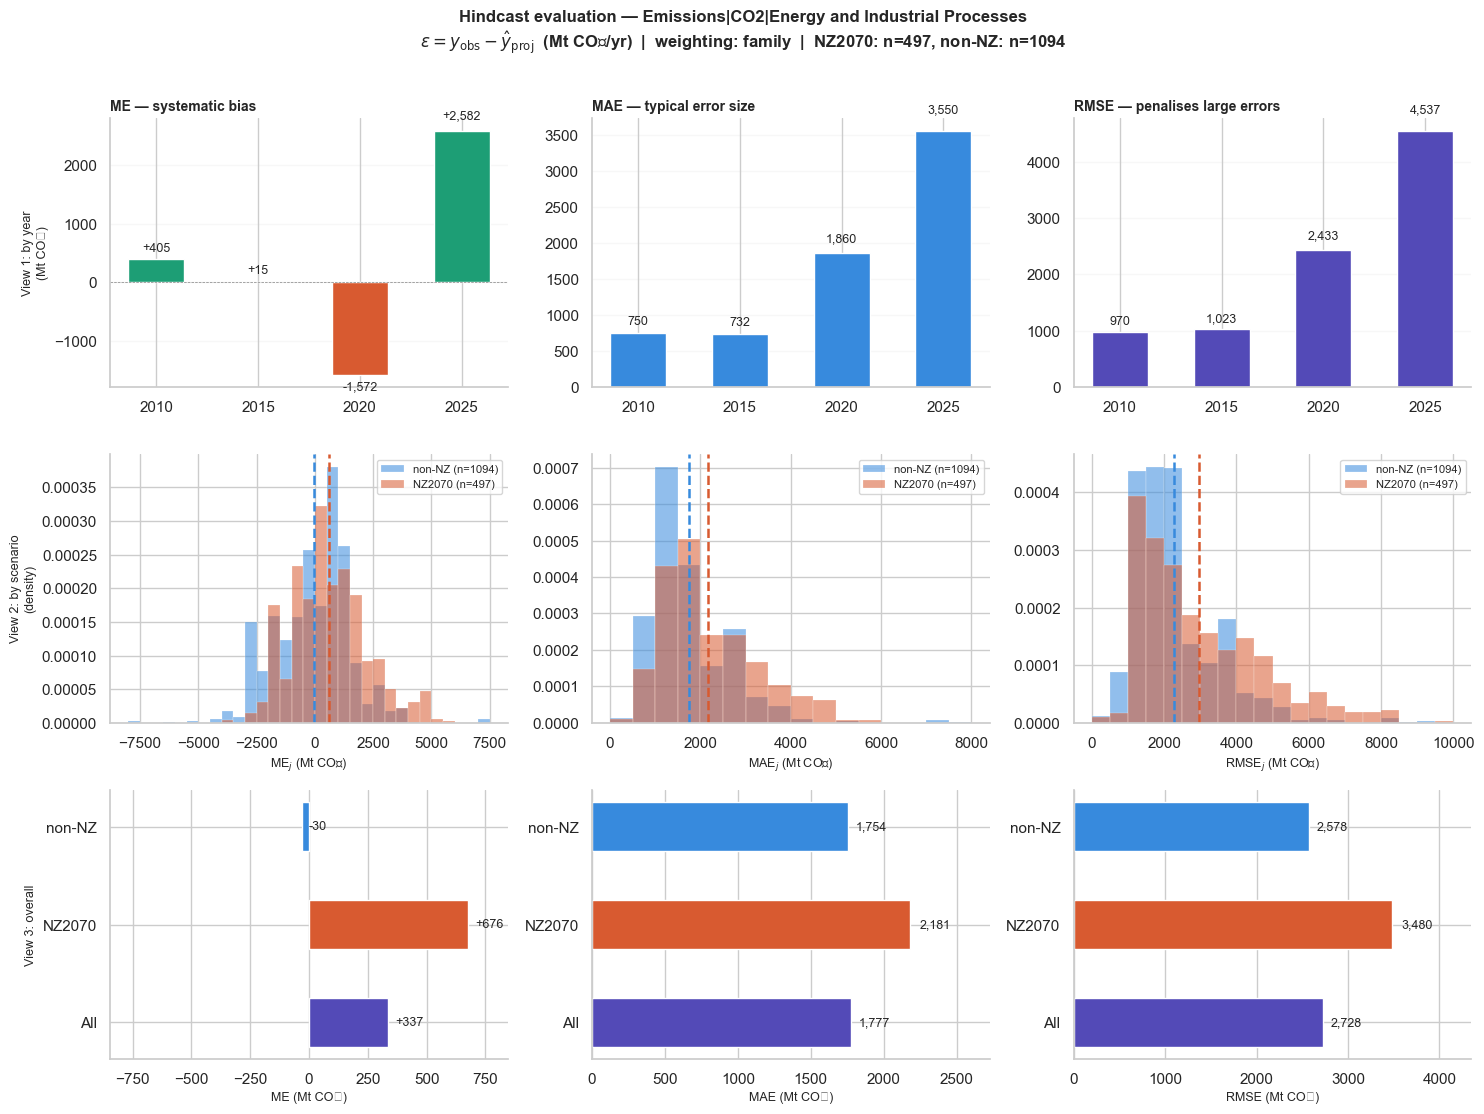

Saved: step1_co2_3x3_weighted.png


In [8]:
C_POS, C_NEG = '#1D9E75', '#D85A30'
C_NZ, C_OT, C_ALL = '#D85A30', '#378ADD', '#534AB7'

# Pre-compute weighted metrics ---------------------------------------
# View 1: weighted, per year
v1 = {m: [] for m in ['ME', 'MAE', 'RMSE']}
for yr in YEARS:
    me, mae, rmse = wmetrics(s[f'eps_{yr}'], w_all)
    v1['ME'].append(me); v1['MAE'].append(mae); v1['RMSE'].append(rmse)

# View 2/3: group subsets and within-group weights
sub_nz, sub_ot = s[s['nz2070']], s[~s['nz2070']]
w_nz, w_ot = weights_for(sub_nz), weights_for(sub_ot)
p_all, p_nz, p_ot = pooled_metrics(s), pooled_metrics(sub_nz), pooled_metrics(sub_ot)
v3 = {'ME': (p_all[0], p_nz[0], p_ot[0]),
      'MAE': (p_all[1], p_nz[1], p_ot[1]),
      'RMSE': (p_all[2], p_nz[2], p_ot[2])}

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle(
    f'Hindcast evaluation — {VARIABLE}\n'
    r'$\varepsilon = y_{\mathrm{obs}} - \hat{y}_{\mathrm{proj}}$'
    f'  (Mt CO₂/yr)  |  weighting: {WEIGHTING}  |  NZ2070: n={n_nz}, non-NZ: n={n_other}',
    fontsize=12, fontweight='bold', y=1.01)

metrics = [('ME', 'systematic bias', True), ('MAE', 'typical error size', False), ('RMSE', 'penalises large errors', False)]

for col, (mname, subtitle, signed) in enumerate(metrics):
    # Row 0: View 1
    ax = axes[0, col]
    vals = v1[mname]
    colors = [C_POS if v >= 0 else C_NEG for v in vals] if signed else [C_OT if mname == 'MAE' else C_ALL] * 4
    bars = ax.bar(YEARS, vals, color=colors, width=0.55)
    if signed: ax.axhline(0, color='gray', lw=0.5, ls='--')
    for bar, v in zip(bars, vals):
        off = max(abs(v)*0.06, 80)
        ax.text(bar.get_x()+bar.get_width()/2, v+(off if v>=0 or not signed else -off),
                f'{v:+,.0f}' if signed else f'{v:,.0f}', ha='center',
                va='bottom' if (v>=0 or not signed) else 'top', fontsize=9)
    ax.set_title(f'{mname} — {subtitle}', fontsize=10, fontweight='bold', loc='left')
    if col == 0: ax.set_ylabel('View 1: by year\n(Mt CO₂)', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.15)

    # Row 1: View 2 — weighted histogram + weighted group means
    ax = axes[1, col]
    mcol = f'{mname}_j'
    m_nz, m_ot = sub_nz[mcol].notna(), sub_ot[mcol].notna()
    v_nz, wn = sub_nz.loc[m_nz, mcol].values, w_nz[m_nz].values
    v_ot, wo = sub_ot.loc[m_ot, mcol].values, w_ot[m_ot].values
    lo, hi = min(v_nz.min(), v_ot.min()), max(v_nz.max(), v_ot.max())
    bins = np.arange(np.floor(lo/500)*500, np.ceil(hi/500)*500+500, 500)
    ax.hist(v_ot, bins=bins, weights=wo, density=True, alpha=0.55, color=C_OT, label=f'non-NZ (n={len(v_ot)})', edgecolor='white', lw=0.3)
    ax.hist(v_nz, bins=bins, weights=wn, density=True, alpha=0.55, color=C_NZ, label=f'NZ2070 (n={len(v_nz)})', edgecolor='white', lw=0.3)
    ax.axvline(wmean(v_ot, wo), color=C_OT, lw=1.8, ls='--')
    ax.axvline(wmean(v_nz, wn), color=C_NZ, lw=1.8, ls='--')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_xlabel(f'{mname}$_j$ (Mt CO₂)', fontsize=9)
    if col == 0: ax.set_ylabel('View 2: by scenario\n(density)', fontsize=9)
    ax.spines[['top','right']].set_visible(False)

    # Row 2: View 3 — weighted, pooled
    ax = axes[2, col]
    vals3 = list(v3[mname])   # (All, NZ2070, non-NZ)
    bars3 = ax.barh(['All','NZ2070','non-NZ'], vals3, color=[C_ALL,C_NZ,C_OT], height=0.5)
    for bar, v in zip(bars3, vals3):
        ax.text(v+max(abs(v)*0.03,30), bar.get_y()+bar.get_height()/2,
                f'{v:+,.0f}' if signed else f'{v:,.0f}', ha='left', va='center', fontsize=9)
    if col == 0: ax.set_ylabel('View 3: overall', fontsize=9)
    ax.set_xlabel(f'{mname} (Mt CO₂)', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    xmax = max(abs(v) for v in vals3) * 1.25
    ax.set_xlim((-xmax, xmax) if signed else (0, xmax))

plt.tight_layout()
plt.savefig('step1_co2_3x3_weighted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step1_co2_3x3_weighted.png')

## Energy-system vs. economy models

Does the model's economic structure matter for hindcast skill? We split the ensemble by `Class`:
**energy-system** (partial-equilibrium, GDP exogenous) vs **economy** (endogenous macro-economy —
CGE or Ramsey growth). Families are balanced *within* each class, so this is a fair model-vs-model
comparison rather than a count of scenarios.

Weighting: family  (families balanced within each class)
Class     |     n | families |       ME      MAE     RMSE
--------------------------------------------------------
energy    |   883 |        7 |      -41    1,882    2,903
economy   |   701 |        8 |     +613    1,761    2,647


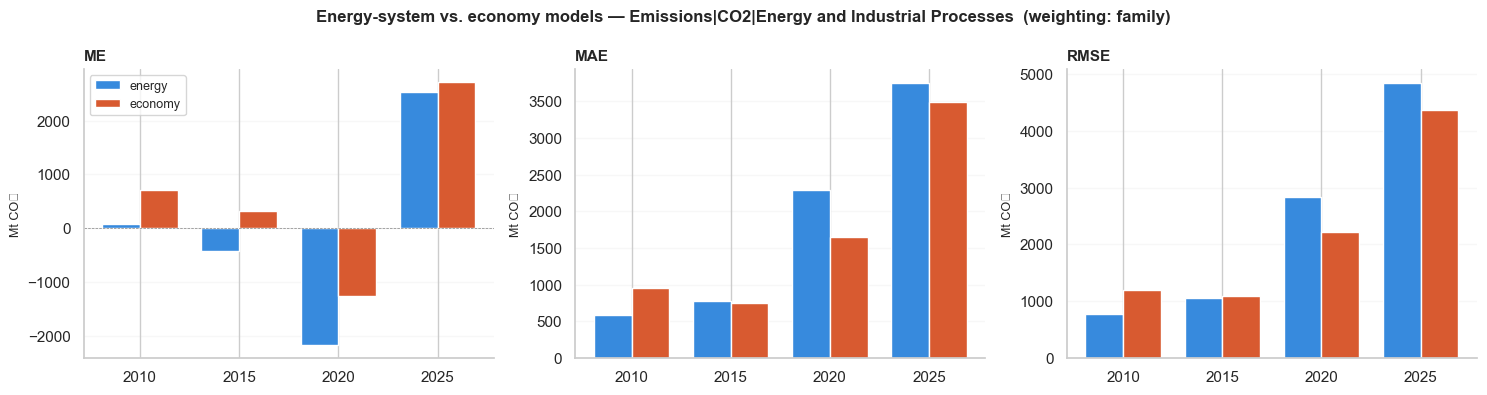

Saved: step1_co2_energy_vs_economy.png


In [9]:
CLASSES = ['energy', 'economy']
C_CLASS = {'energy': '#378ADD', 'economy': '#D85A30'}
MI = {'ME': 0, 'MAE': 1, 'RMSE': 2}

print(f'Weighting: {WEIGHTING}  (families balanced within each class)')
print(f'{"Class":<9} | {"n":>5} | {"families":>8} | {"ME":>8} {"MAE":>8} {"RMSE":>8}')
print('-' * 56)
for cl in CLASSES:
    sub = s[s['Class'] == cl]
    me, mae, rmse = pooled_metrics(sub)
    print(f'{cl:<9} | {len(sub):>5} | {sub["Family"].nunique():>8} | '
          f'{me:>+8,.0f} {mae:>8,.0f} {rmse:>8,.0f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Energy-system vs. economy models — {VARIABLE}  (weighting: {WEIGHTING})',
             fontsize=12, fontweight='bold')
x = np.arange(len(YEARS)); bw = 0.38
for ax, (mname, signed) in zip(axes, [('ME', True), ('MAE', False), ('RMSE', False)]):
    for k, cl in enumerate(CLASSES):
        sub = s[s['Class'] == cl]
        wsub = weights_for(sub)
        vals = [wmetrics(sub[f'eps_{yr}'], wsub)[MI[mname]] for yr in YEARS]
        ax.bar(x + (k - 0.5) * bw, vals, bw, label=cl, color=C_CLASS[cl])
    if signed: ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xticks(x); ax.set_xticklabels(YEARS)
    ax.set_title(mname, fontsize=11, fontweight='bold', loc='left')
    ax.set_ylabel('Mt CO₂', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.15)
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig('step1_co2_energy_vs_economy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: step1_co2_energy_vs_economy.png')